## Матрица рассеяния (Scatter Matrix)

In [12]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

## 1 Установливаем соединение с базой данных.

In [13]:
conn = sqlite3.connect('/Users/cleganeb/Desktop/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/data/checking-logs.sqlite')

## 2 Пронализируем пользователей из таблицы pageviews, выведем уникальный идентификатор пользователя и числа просмотров.

In [14]:
query = """
SELECT  uid,
        COUNT(*) AS pageviews
FROM pageviews
WHERE uid LIKE 'user_%'
GROUP BY uid
ORDER BY uid ASC
"""
pageviews = pd.io.sql.read_sql(query, conn)

display(pageviews)

,uid,pageviews
0,user_1,28
1,user_10,89
2,user_14,143
3,user_17,47
4,user_18,3
5,user_19,16
6,user_21,10
7,user_25,179
8,user_28,149
9,user_3,317


## 3 Пронализируем пользователей из таблицы checker, выведем уникальный идентификатор пользователя, название проекта, количество выполненных коммитов.

In [15]:
query = """
SELECT *
FROM checker
WHERE uid LIKE 'user_%'
ORDER BY uid ASC
"""
checker = pd.io.sql.read_sql(query, conn)
display(checker.head())

,index,status,success,timestamp,numTrials,labname,uid
0,163,ready,0,2020-04-20 17:56:45.209722,1,lab02,user_0
1,164,checking,0,2020-04-20 17:56:58.021415,2,lab02,user_0
2,165,ready,0,2020-04-20 17:56:58.195472,2,lab02,user_0
3,519,ready,0,2020-04-26 17:06:18.462708,1,laba04,user_1
4,520,checking,0,2020-04-26 17:06:58.256753,2,laba04,user_1


In [16]:
test = pd.io.sql.read_sql("SELECT * FROM test", conn)
display(test.head())

,uid,labname,first_commit_ts,first_views_ts
0,user_1,laba04,2020-04-26 17:06:18.462708,2020-04-26 21:53:59.624136
1,user_1,laba04s,2020-04-26 17:12:11.843671,2020-04-26 21:53:59.624136
2,user_1,laba05,2020-05-02 19:15:18.540185,2020-04-26 21:53:59.624136
3,user_1,laba06,2020-05-17 16:26:35.268534,2020-04-26 21:53:59.624136
4,user_1,laba06s,2020-05-20 12:23:37.289724,2020-04-26 21:53:59.624136


In [17]:
query = """
WITH first_and_deadline AS (
    SELECT 
        c.uid,
        c.labname,
        MIN(c.timestamp) AS first_ts,
        d.deadlines
    FROM checker c
    LEFT JOIN deadlines d ON c.labname = d.labs
    WHERE c.labname != 'project1' AND c.uid LIKE 'user_%'
    GROUP BY c.uid, c.labname
)
SELECT 
    f.uid,
    AVG((STRFTIME('%s', f.first_ts) - f.deadlines) / 3600.) AS avg_diff,
    (SELECT COUNT(*) 
    FROM checker c 
    WHERE c.uid = f.uid AND c.labname != 'project1') AS num_commits
FROM first_and_deadline f
GROUP BY f.uid
ORDER BY f.uid ASC
"""
avg_checker = pd.io.sql.read_sql(query, conn)
display(avg_checker.head())

,uid,avg_diff,num_commits
0,user_0,NaN,3
1,user_1,-65.119778,62
2,user_10,-75.242444,20
3,user_11,-2.884444,7
4,user_12,-89.450764,86


## 4 Объеденим полученные результаты в 1 таблицу.

In [18]:
final_df = pd.merge(left=avg_checker, right=pageviews,on='uid',how='inner')
new_column_order = ['uid', 'avg_diff', 'pageviews', 'num_commits']
final_df = final_df.reindex(columns=new_column_order)
display(final_df)

,uid,avg_diff,pageviews,num_commits
0,user_1,-65.119778,28,62
1,user_10,-75.242444,89,20
2,user_14,-159.568796,143,61
3,user_17,-62.207667,47,51
4,user_18,-6.368148,3,5
5,user_19,-99.440417,16,118
6,user_21,-96.111181,10,65
7,user_25,-93.474944,179,79
8,user_28,-86.793833,149,60
9,user_3,-105.738222,317,18


## 5 Построим график, на котором отображаются точки и линии плотности распределения.

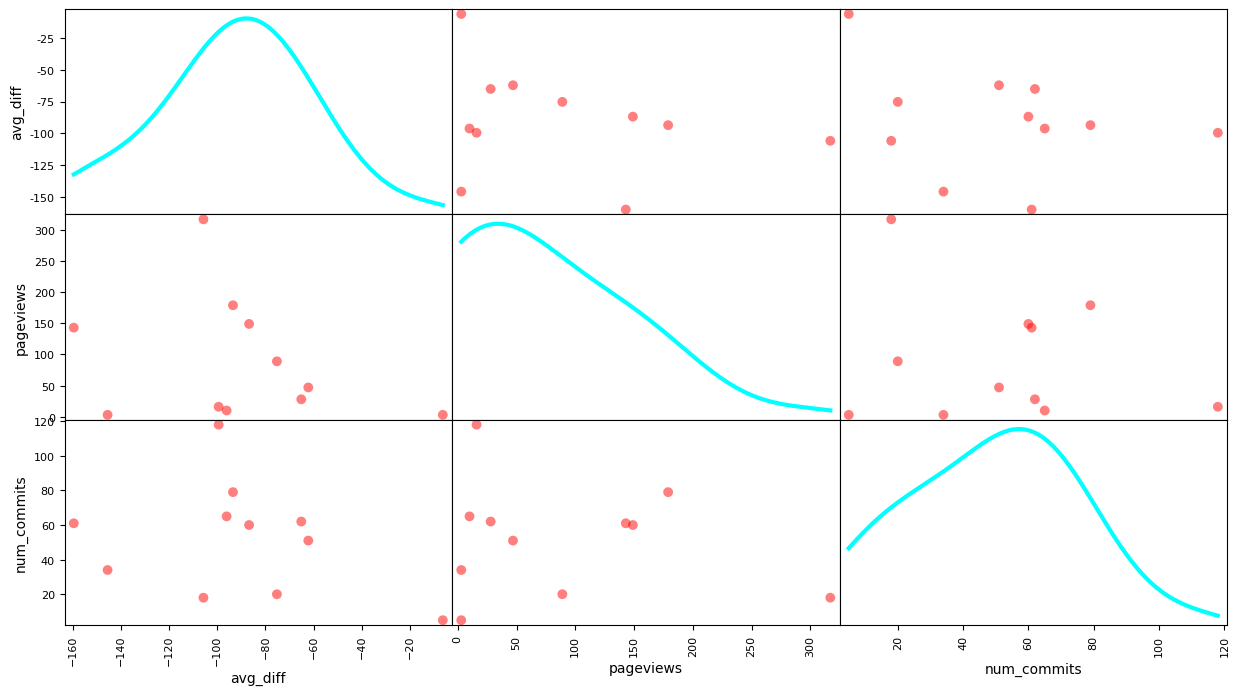

In [19]:
scatter_matrix(
    final_df,
    diagonal='kde',
    marker='.',
    figsize=(15,8),
    s = 200,
    color = 'red',
    density_kwds={'color': 'cyan','lw':3}
    )

plt.show()


## 6 Можно ли сказать, что если у пользователя низкое количество просмотров страниц (pageviews), то у него вероятно низкое количество коммитов?
## Можно ли утверждать, что если у пользователя малое количество просмотров страницы, то у него, вероятно, маленькая средняя разница между первым коммитом и дедлайном лаборатории?
## Можно ли утверждать, что большинство пользователей имеют малое количество коммитов, а меньшинство — большое количество?
## Можно ли утверждать, что большинство пользователей имеют небольшую среднюю разницу, а меньшинство — большую среднюю разницу?

In [20]:
print("нет, нет, да, нет")

нет, нет, да, нет


## 7 Закроем соединение с базой данных.

In [21]:
conn.close()